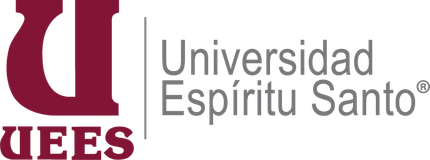

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 1 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E0 · Entorno reproducible</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Dejar listo un entorno que ejecute todos los notebooks del curso y una estructura de repositorio reproducible. |
| **Resultado de aprendizaje** | RDA1 · norma d del sílabo (repositorio reproducible) |
| **Duración** | ≈ 1.5 h (laboratorio guiado del sábado) |
| **Teoría** | Manual M1 §8 · Reproducibilidad |
| **Datos** | `load_iris` (incluido en scikit-learn) |

**Cómo trabajar:** ejecuta las celdas de arriba hacia abajo. Donde veas `# TODO` completa el código. Las celdas de **autoverificación** al final te dicen si todo quedó bien.

## Paso 1 · Instalar el entorno

Tienes dos caminos. Elige uno.

**A. En tu computador con `uv` (recomendado).** `uv` crea el entorno y fija las versiones en `uv.lock`, así cualquiera reproduce tu trabajo con un solo comando.

```bash
# instala uv: https://docs.astral.sh/uv/getting-started/installation/
uv init miar0525 && cd miar0525
uv python pin 3.13
uv add scikit-learn pandas numpy matplotlib jupyterlab mlflow
uv run jupyter lab
```

**B. En Google Colab.** Abre este notebook desde el hub con el botón *Abrir en Colab*, guarda una copia en tu Drive y ejecuta la celda siguiente, que instala lo que Colab no trae.

In [1]:
# En Colab instala MLflow si falta. En tu computador esta celda no hace nada.
import importlib.util
import sys

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB and importlib.util.find_spec("mlflow") is None:
    %pip install -q mlflow
print("Ejecutando en Google Colab" if EN_COLAB else "Ejecutando en un entorno local")

Ejecutando en un entorno local


## Paso 2 · Verificar versiones

El curso usa **Python 3.13 o 3.14** y **scikit-learn 1.5 o superior** (en el laboratorio se usa 1.9). La celda imprime las versiones y se detiene con un mensaje claro si algo no cumple.

In [2]:
import platform

import matplotlib
import numpy as np
import pandas as pd
import sklearn

VERSIONES = {
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "Matplotlib": matplotlib.__version__,
}
for nombre, version in VERSIONES.items():
    print(f"{nombre:<13} {version}")


def version_tupla(texto):
    """'1.9.1' → (1, 9)"""
    return tuple(int(p) for p in texto.split(".")[:2])


assert sys.version_info >= (3, 12), "Usa Python 3.12 o superior (recomendado 3.13 o 3.14)."
assert version_tupla(sklearn.__version__) >= (1, 5), "Actualiza scikit-learn a 1.5 o superior."
print("\n✓ Versiones compatibles con el curso")

Python        3.13.14
NumPy         2.5.3
pandas        3.0.5
scikit-learn  1.9.1
Matplotlib    3.11.2

✓ Versiones compatibles con el curso


## Paso 3 · Semilla fija y estilo institucional

Toda fuente de azar del curso usa la misma semilla, `SEED = 2026`. Con una semilla fija, dos ejecuciones producen exactamente los mismos números: esa es la base de la reproducibilidad.

Los gráficos usan la paleta de la UEES (vino `#821436`, azul petróleo, ocre, verde y gris). Es la misma que `utils/uees.mplstyle`.

In [3]:
import matplotlib.pyplot as plt
from cycler import cycler

SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())),
    "axes.titlecolor": UEES["vino"], "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})

# TODO: crea dos generadores con la misma semilla y comprueba que producen los mismos números.
gen_a = np.random.default_rng(SEED)
gen_b = np.random.default_rng(SEED)
muestra_a, muestra_b = gen_a.normal(size=5), gen_b.normal(size=5)
print(muestra_a.round(3))
print(muestra_b.round(3))
print("¿Idénticas?", np.array_equal(muestra_a, muestra_b))

[-0.793  0.241 -1.896  1.396  0.638]
[-0.793  0.241 -1.896  1.396  0.638]
¿Idénticas? True


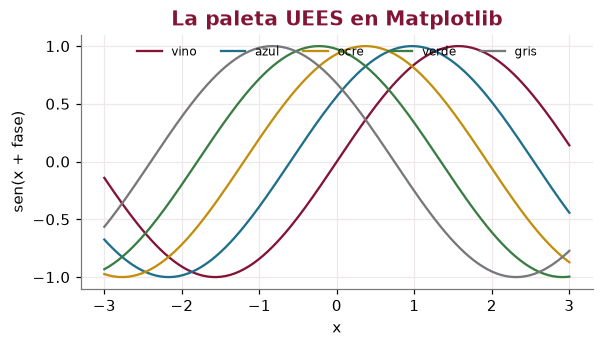

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
x = np.linspace(-3, 3, 200)
for k, nombre in enumerate(UEES):
    ax.plot(x, np.sin(x + k * 0.6), label=nombre)
ax.set(title="La paleta UEES en Matplotlib", xlabel="x", ylabel="sen(x + fase)")
ax.legend(ncols=5, fontsize=8, loc="upper center")
plt.show()

## Paso 4 · Estructura del repositorio

Todas tus entregas usan la misma estructura. Así cualquier persona encuentra lo que busca y puede ejecutarlo:

```
miar0525_proyecto/
├── README.md          ← qué es, cómo se ejecuta y qué resultados esperar
├── pyproject.toml     ← dependencias (lo crea uv)
├── .gitignore         ← datos, cachés y resultados temporales fuera de git
├── data/              ← vacía en git: los datos se descargan por código
├── notebooks/
├── src/               ← funciones reutilizables
└── reports/           ← informe, figuras y reports/prompts.md (uso de IA)
```

In [5]:
from pathlib import Path

README = """# Proyecto MIAR0525

## Cómo ejecutar
1. Instala uv y ejecuta `uv sync`.
2. Abre los notebooks con `uv run jupyter lab`.

## Uso de IA
Ver `reports/prompts.md`.
"""
GITIGNORE = "data/\n.venv/\n__pycache__/\n.ipynb_checkpoints/\nmlruns/\nmlflow.db\n"


def crear_estructura(raiz):
    """Crea las carpetas y archivos base del proyecto dentro de `raiz` y devuelve la ruta."""
    raiz = Path(raiz)
    # TODO: crea las carpetas data, notebooks, src y reports, y escribe README.md y .gitignore.
    for carpeta in ("data", "notebooks", "src", "reports"):
        (raiz / carpeta).mkdir(parents=True, exist_ok=True)
    (raiz / "README.md").write_text(README, encoding="utf-8")
    (raiz / ".gitignore").write_text(GITIGNORE, encoding="utf-8")
    (raiz / "reports" / "prompts.md").write_text("# Uso de IA generativa\n\n(Declara aquí herramienta, propósito y prompts relevantes.)\n", encoding="utf-8")
    return raiz


proyecto = crear_estructura("miar0525_proyecto")
for ruta in sorted(proyecto.rglob("*")):
    print(ruta.relative_to(proyecto.parent))

miar0525_proyecto/.gitignore
miar0525_proyecto/README.md
miar0525_proyecto/data
miar0525_proyecto/notebooks
miar0525_proyecto/reports
miar0525_proyecto/reports/prompts.md
miar0525_proyecto/src


## Paso 5 · Tu primer experimento en MLflow

Desde la semana 2 registrarás cada experimento en **MLflow** (BC7): parámetros, métricas y modelos quedan guardados y se pueden comparar. Aquí comprobamos que funciona con un modelo sencillo sobre `iris`.

Para ver la interfaz: `uv run mlflow ui --backend-store-uri sqlite:///mlflow.db` y abre http://127.0.0.1:5000

In [6]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X, y = load_iris(return_X_y=True)
modelo = LogisticRegression(max_iter=1000)
puntajes = cross_val_score(modelo, X, y, cv=5)
print(f"Exactitud en validación cruzada: {puntajes.mean():.3f} ± {puntajes.std():.3f}")

try:
    import logging

    import mlflow

    logging.getLogger("mlflow").setLevel(logging.WARNING)   # menos mensajes informativos

    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("E0-prueba")
    with mlflow.start_run(run_name="regresion-logistica-iris") as corrida:
        mlflow.log_param("modelo", "LogisticRegression")
        mlflow.log_param("seed", SEED)
        mlflow.log_metric("exactitud_cv", float(puntajes.mean()))
    RUN_ID = corrida.info.run_id
    print("✓ Corrida registrada en MLflow:", RUN_ID)
except ImportError:
    RUN_ID = None
    print("MLflow no está instalado: ejecuta `uv add mlflow` (o la celda del paso 1 en Colab).")

Exactitud en validación cruzada: 0.973 ± 0.025


/home/andresrubiop/Documents/MLUees/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Corrida registrada en MLflow: f71ab4fdf32e43688de6ed2a70a1aa09


## Autoverificación

Si todas las comprobaciones pasan, tu entorno está listo para el curso.

In [7]:
assert SEED == 2026, "La semilla del curso es 2026."
assert np.array_equal(muestra_a, muestra_b), "Los dos generadores deben usar la misma semilla."
for carpeta in ("data", "notebooks", "src", "reports"):
    assert (proyecto / carpeta).is_dir(), f"Falta la carpeta {carpeta}/"
assert (proyecto / "README.md").exists() and (proyecto / ".gitignore").exists(), "Faltan README.md o .gitignore"
if RUN_ID is None:
    print("⚠ Instala MLflow antes de la semana 2.")
print("✓ E0 completo: entorno, semilla, estilo, estructura y MLflow")

✓ E0 completo: entorno, semilla, estilo, estructura y MLflow


## Lista de cotejo (autoevaluación)

- [ ] Imprimí las versiones y son compatibles.
- [ ] Fijé la semilla `SEED = 2026` y comprobé que los resultados se repiten.
- [ ] Creé la estructura del repositorio con `README.md` y `.gitignore`.
- [ ] Registré una corrida en MLflow y la vi en la interfaz.

**Cómo te prepara para la Tarea 1:** la tarea se entrega en un repositorio con esta misma estructura, un `README` con los pasos exactos y la semilla fija en todos los pasos.

## Desafío opcional con IA agéntica · Tu entorno, verificado por un agente

**Objetivo.** Pedirle a un agente que prepare y compruebe un entorno reproducible del curso, y aprender a revisar lo que hizo.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
Estoy en un curso de aprendizaje automático. En este repositorio hay un notebook de entorno (E0) y un pyproject.toml. Muéstrame primero un plan y espera mi aprobación. Después crea un entorno con uv y Python 3.13 usando solo las dependencias de pyproject.toml, ejecuta el notebook de principio a fin y escribe un README con los pasos exactos, las versiones instaladas y el tiempo de ejecución. No instales nada que no esté declarado.
```

**Cómo verificar el resultado**

- El notebook corre de cero en un entorno limpio y las versiones coinciden con uv.lock.
- Otra persona puede repetir los pasos del README sin preguntarte nada.
- Revisaste cada comando que el agente ejecutó antes de aprobarlo.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.